<a href="https://colab.research.google.com/github/BibianaNovakova/Bakalarska_praca/blob/main/3_kapitola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

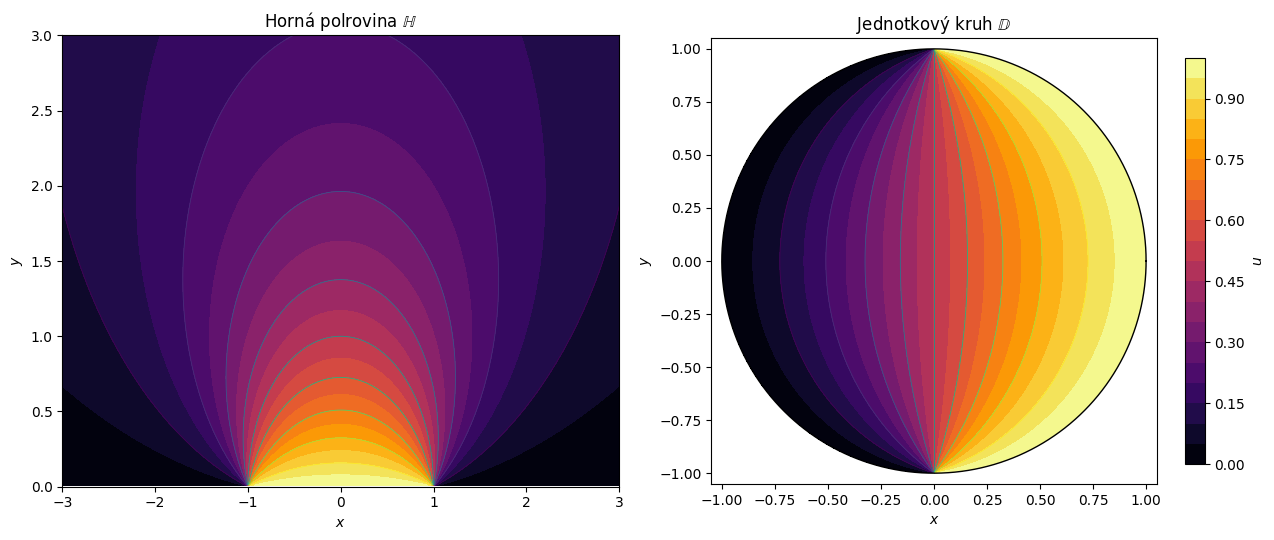

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def u_halfplane(x, y):
    return (1 / np.pi) * (
        np.arctan((1 - x) / y) + np.arctan((1 + x) / y)
    )

def x_y_from_disk(r, theta):
    denom = 1 + r**2 + 2 * r * np.cos(theta)
    x = 2 * r * np.sin(theta) / denom
    y = (1 - r**2) / denom
    return x, y

def u_disk(r, theta):
    x, y = x_y_from_disk(r, theta)
    return u_halfplane(x, y)

nx, ny = 600, 400
x = np.linspace(-3, 3, nx)
y = np.linspace(0.01, 3, ny)  # y > 0

Xh, Yh = np.meshgrid(x, y)
Uh = u_halfplane(Xh, Yh)

n = 600
x = np.linspace(-1.05, 1.05, n)
y = np.linspace(-1.05, 1.05, n)

Xd, Yd = np.meshgrid(x, y)
R = np.sqrt(Xd**2 + Yd**2)
Theta = np.arctan2(Yd, Xd)

Ud = np.full_like(R, np.nan, dtype=float)
mask = R < 1.0
Ud[mask] = u_disk(R[mask], Theta[mask])



fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

levels = np.linspace(0, 1, 21)

ax = axes[0]

cf1 = ax.contourf(Xh, Yh, Uh, levels=levels, cmap='inferno')
ax.contour(Xh, Yh, Uh, levels=np.linspace(0.1, 0.9, 9), linewidths=0.6)

ax.set_xlim(-3, 3)
ax.set_ylim(0, 3)
ax.set_title(r'Horná polrovina $\mathbb{H}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

ax = axes[1]

cf2 = ax.contourf(Xd, Yd, Ud, levels=levels, cmap='inferno')
ax.contour(Xd, Yd, Ud, levels=np.linspace(0.1, 0.9, 9), linewidths=0.6)

t = np.linspace(0, 2 * np.pi, 1000)
ax.plot(np.cos(t), np.sin(t), color='black', linewidth=1)

ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_title(r'Jednotkový kruh $\mathbb{D}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

# COLORBAR
cbar = fig.colorbar(cf2, ax=axes[1], shrink=0.9)
cbar.set_label(r'$u$')

plt.subplots_adjust(wspace=0.25)
plt.tight_layout()
plt.show()

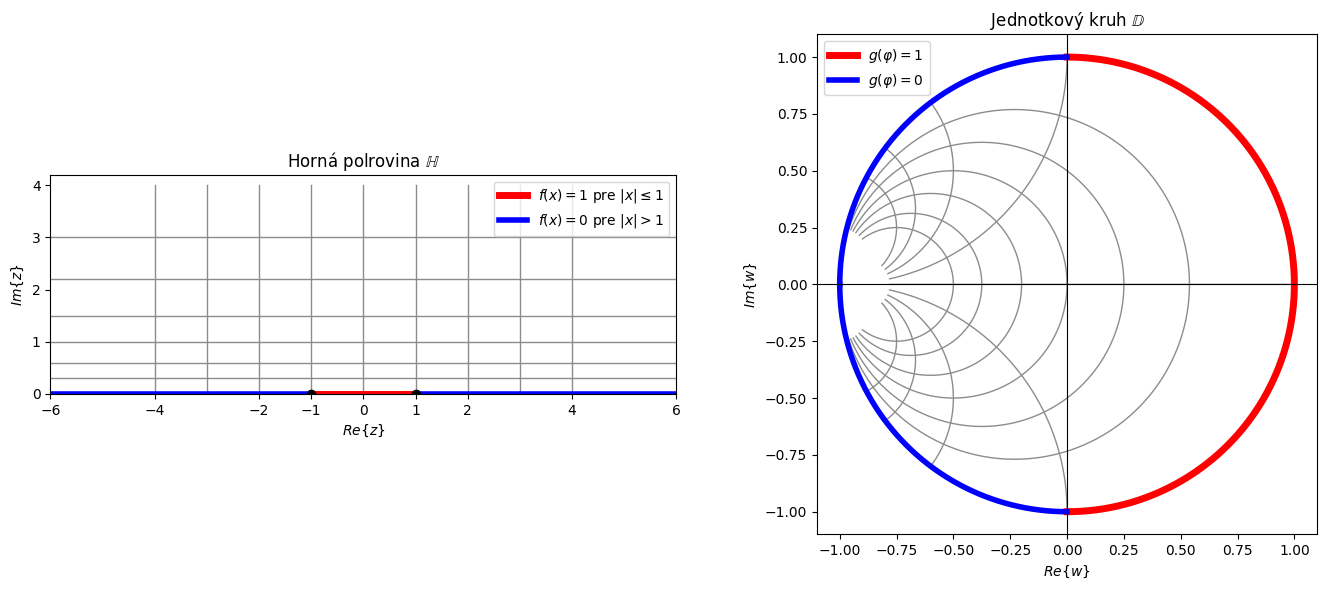

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def mobius(z):
    return (1j - z) / (1j + z)



fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Farby
grid_color = "0.55"
highlight_red = "red"
highlight_blue = "blue"

ax = axes[0]

xs = np.linspace(-6, 6, 800)
for y in [0.3, 0.6, 1.0, 1.5, 2.2, 3.0]:
    ax.plot(xs, y * np.ones_like(xs), color=grid_color, linewidth=1)

ys = np.linspace(0.05, 4.0, 500)
for x in [-4, -3, -2, -1, 0, 1, 2, 3, 4]:
    ax.plot(x * np.ones_like(ys), ys, color=grid_color, linewidth=1)

# reálna os – rozdelená podľa okrajovej podmienky
ax.plot([-6, -1], [0, 0], color=highlight_blue, linewidth=4, solid_capstyle='butt')
ax.plot([-1, 1], [0, 0], color=highlight_red, linewidth=5, solid_capstyle='butt')
ax.plot([1, 6], [0, 0], color=highlight_blue, linewidth=4, solid_capstyle='butt')

# body -1 a 1 na osi x
ax.plot([-1, 1], [0, 0], 'ko', markersize=6, zorder=5)

ax.set_xlim(-6, 6)
ax.set_ylim(0, 4.2)
ax.set_aspect('equal')
ax.set_title(r'Horná polrovina $\mathbb{H}$')
ax.set_xlabel(r'$Re \{z\}$')
ax.set_ylabel(r'$Im \{z\}$')

ax.set_xticks([-6, -4, -2, -1, 0, 1, 2, 4, 6])

ax.plot([], [], color=highlight_red, linewidth=5, label=r'$f(x)=1$ pre $|x|\leq 1$')
ax.plot([], [], color=highlight_blue, linewidth=4, label=r'$f(x)=0$ pre $|x|>1$')
ax.legend(loc='upper right', frameon=True)

ax = axes[1]

# obrazy horizontálnych čiar
xs = np.linspace(-8, 8, 2000)
for y in [0.3, 0.6, 1.0, 1.5, 2.2, 3.0]:
    z = xs + 1j * y
    w = mobius(z)
    ax.plot(np.real(w), np.imag(w), color=grid_color, linewidth=1)

# obrazy vertikálnych čiar
ys = np.linspace(0.001, 8.0, 2000)
for x in [-4, -3, -2, -1, 0, 1, 2, 3, 4]:
    z = x + 1j * ys
    w = mobius(z)
    ax.plot(np.real(w), np.imag(w), color=grid_color, linewidth=1)

# jednotková kružnica so zvýraznenou hranicou
t_right = np.linspace(-np.pi / 2, np.pi / 2, 400)
t_left_1 = np.linspace(np.pi / 2, np.pi, 200)
t_left_2 = np.linspace(-np.pi, -np.pi / 2, 200)

ax.plot(np.cos(t_right), np.sin(t_right),
        color=highlight_red, linewidth=5, label=r'$g(\varphi)=1$')
ax.plot(np.cos(t_left_1), np.sin(t_left_1),
        color=highlight_blue, linewidth=4, label=r'$g(\varphi)=0$')
ax.plot(np.cos(t_left_2), np.sin(t_left_2),
        color=highlight_blue, linewidth=4)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.set_title(r'Jednotkový kruh $\mathbb{D}$')
ax.set_xlabel(r'$Re \{w\}$')
ax.set_ylabel(r'$Im \{w\}$')
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

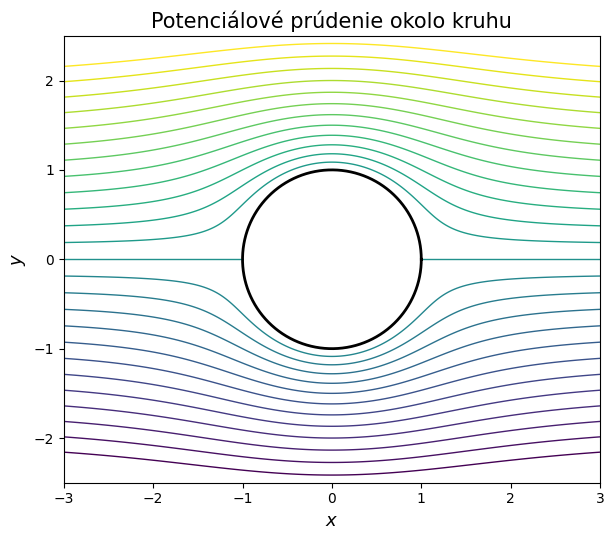

In [7]:
import numpy as np
import matplotlib.pyplot as plt


U = 1.0
a = 1.0
N = 700

# Prúdová funkcia okolo kružnice

def stream_function_cylinder(zeta):
    return np.imag(U * (zeta + a**2 / zeta))


x = np.linspace(-3, 3, N)
y = np.linspace(-2.5, 2.5, N)

X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Výpočet prúdovej funkcie

mask = np.abs(Z) >= a

Psi = np.full(Z.shape, np.nan)
Psi[mask] = stream_function_cylinder(Z[mask])


fig, ax = plt.subplots(figsize=(8, 5.5))

levels = np.linspace(-2, 2, 25)

ax.contour(
    X,
    Y,
    np.ma.masked_invalid(Psi),
    levels=levels,
    linewidths=1.0
)

# kružnica
t = np.linspace(0, 2*np.pi, 1000)

circle = a * np.exp(1j * t)

ax.plot(
    circle.real,
    circle.imag,
    color='black',
    linewidth=2
)


ax.set_aspect('equal')

ax.set_xlim(-3, 3)
ax.set_ylim(-2.5, 2.5)

ax.set_xlabel(r'$x$', fontsize=13)
ax.set_ylabel(r'$y$', fontsize=13)

ax.set_title(r'Potenciálové prúdenie okolo kruhu', fontsize=15)

plt.tight_layout()
plt.show()

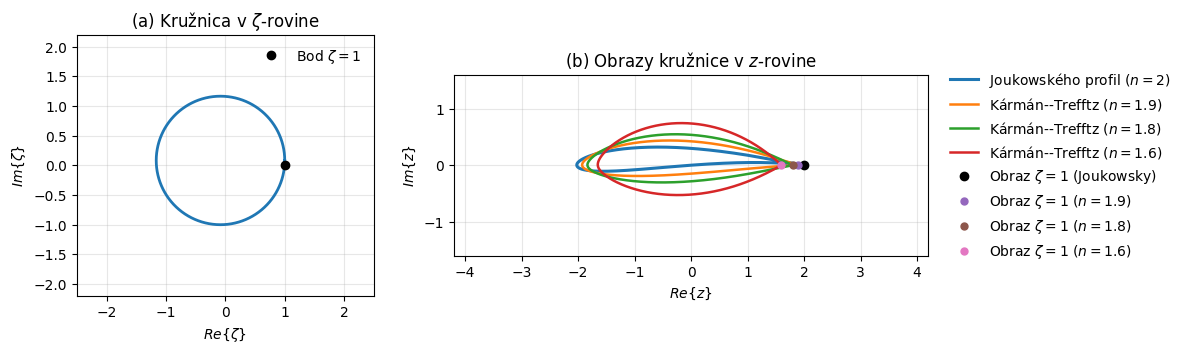

In [13]:
import numpy as np
import matplotlib.pyplot as plt


def joukowski(zeta):
    return zeta + 1/zeta


def karman_trefftz(zeta, n=2):
    return n * ((zeta + 1)**n + (zeta - 1)**n) / \
               ((zeta + 1)**n - (zeta - 1)**n)


mu = -0.08 + 0.08j
R = abs(1 - mu)


def figure_airfoil_shapes_like_matthews():

    t = np.linspace(0, 2*np.pi, 4000)

    zeta_circle = mu + R*np.exp(1j*t)

    z_joukowski = joukowski(zeta_circle)

    n_values = [2.0, 1.9, 1.8, 1.6]

    kt_profiles = [
        karman_trefftz(zeta_circle, n=n)
        for n in n_values
    ]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5.5),
        gridspec_kw={'width_ratios':[1,1.6]}
    )


    ax = axes[0]

    ax.plot(
        np.real(zeta_circle),
        np.imag(zeta_circle),
        linewidth=2
    )

    ax.plot(
        1,
        0,
        'ko',
        markersize=6,
        zorder=20,
        label=r'Bod $\zeta=1$'
    )

    ax.set_aspect('equal')

    ax.set_xlim(-2.5,2.5)
    ax.set_ylim(-2.2,2.2)

    ax.set_xlabel(r'$Re\{\zeta\}$')
    ax.set_ylabel(r'$Im\{\zeta\}$')

    ax.set_title(r'(a) Kružnica v $\zeta$-rovine')

    ax.grid(alpha=0.3)

    ax.legend(frameon=False)



    ax=axes[1]

    ax.plot(
        np.real(z_joukowski),
        np.imag(z_joukowski),
        linewidth=2.2,
        label=r'Joukowského profil ($n=2$)'
    )

    for n,z_kt in zip(n_values[1:],kt_profiles[1:]):

        ax.plot(
            np.real(z_kt),
            np.imag(z_kt),
            linewidth=1.8,
            label=rf'Kármán--Trefftz ($n={n}$)'
        )

    # obraz bodu pre Joukowského
    z_point_j = joukowski(1+0j)

    ax.plot(
        np.real(z_point_j),
        np.imag(z_point_j),
        'ko',
        markersize=6,
        zorder=20,
        label=r'Obraz $\zeta=1$ (Joukowsky)'
    )

    # obrazy bodu pre Kármán–Trefftz
    for n in n_values[1:]:

        z_point_kt = karman_trefftz(1+0j,n=n)

        ax.plot(
            np.real(z_point_kt),
            np.imag(z_point_kt),
            'o',
            markersize=5,
            zorder=20,
            label=rf'Obraz $\zeta=1$ ($n={n}$)'
        )

    ax.set_aspect('equal')

    ax.set_xlim(-4.2,4.2)
    ax.set_ylim(-1.6,1.6)

    ax.set_xlabel(r'$Re\{z\}$')
    ax.set_ylabel(r'$Im\{z\}$')

    ax.set_title(r'(b) Obrazy kružnice v $z$-rovine')

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02,0.5),
        frameon=False
    )

    ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0,0,0.80,1])

    plt.show()


figure_airfoil_shapes_like_matthews()